# Лабораторная работа №4: Реализация многослойного перцептрона с обратным распространением ошибки

**Цель работы:**
Реализовать многослойный перцептрон (MLP) с нуля, исследовать оптимизаторы и методы регуляризации.

## Задачи
1. Реализовать класс `MyMLP` с поддержкой произвольного числа скрытых слоев и нейронов.
2. Реализовать функции активации: Sigmoid, Tanh, ReLU, Leaky ReLU и их производные.
3. Инициализация весов: Xavier, He.
4. Реализовать алгоритм обратного распространения:
   - Прямой проход (forward pass)
   - Обратный проход (backpropagation) для всех слоев
5. Реализовать оптимизаторы:
   - SGD
   - SGD с momentum
   - RMSprop
   - Adam
6. Реализовать методы регуляризации:
   - L2-регуляризация
   - Dropout
   - Batch Normalization (упрощённая)
   - Early stopping по валидационной выборке
7. Исследовать влияние гиперпараметров:
   - Learning rate
   - Batch size
   - Архитектура сети (слои, нейроны)
8. Провести эксперименты на данных:
   - MNIST (subset 10000 образцов)
   - Fashion-MNIST (subset 10000 образцов)
   - Cifar-10 (subset 5000 образцов, предобработать в grayscale или уменьшить размер)
9. Сравнить с реализациями из PyTorch/TensorFlow по качеству и скорости.

## Источники данных
```
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1)
X_mnist, y_mnist = mnist.data / 255.0, mnist.target.astype(int)
```

## Критерии оценивания (15 баллов)
- Реализация forward/backward pass — 5 баллов
- Оптимизаторы и регуляризация — 4 балла
- Эксперименты и подбор гиперпараметров — 4 балла
- Сравнение с фреймворками и отчёт — 2 балл

In [1]:
# Импорт библиотек
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Загрузка MNIST subset
mnist = fetch_openml('mnist_784', version=1, cache=False)
X, y = mnist.data.values / 255.0, mnist.target.astype(int)
X_sub, _, y_sub, _ = train_test_split(X, y, train_size=10000, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42)

### 1. Функции активации и их производные
Реализуйте:
- `sigmoid(x)` / `sigmoid_grad(x)`
- `tanh(x)` / `tanh_grad(x)`
- `relu(x)` / `relu_grad(x)`
- `leaky_relu(x, alpha=0.01)` / `leaky_relu_grad(x, alpha=0.01)`

In [2]:
import numpy as np

def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_grad(x):
    t = tanh(x)
    return 1 - t * t

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(np.float32)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_grad(x, alpha=0.01):
    return np.where(x > 0, 1.0, alpha)

def softmax(x):
    shift = np.max(x, axis=0, keepdims=True)
    exps = np.exp(x - shift)
    return exps / np.sum(exps, axis=0, keepdims=True)

# Вспомогательная функция для получения активации и градиента
ACTIVATIONS = {
    'sigmoid': (sigmoid, sigmoid_grad),
    'tanh': (tanh, tanh_grad),
    'relu': (relu, relu_grad),
    'leaky_relu': (leaky_relu, leaky_relu_grad),
    'softmax': (softmax, None),
    'linear': (lambda x: x, lambda x: np.ones_like(x))
}

def get_activation(name):
    if name not in ACTIVATIONS:
        raise ValueError(f"Unknown activation: {name}")
    return ACTIVATIONS[name]

### 2. Класс MyMLP
Реализуйте методы:
- `__init__(self, layer_sizes, activations, weight_init='xavier', optimizer='sgd', **opt_params)`
- `forward(self, X)`
- `backward(self, X, y)`
- `update_weights(self)`
- `fit(self, X, y, X_val, y_val, epochs, batch_size)`
- `predict(self, X)`

In [3]:
from sklearn.preprocessing import OneHotEncoder

class MyMLP:
    def __init__(
        self,
        layer_sizes,
        activations,
        weight_init='xavier',
        optimizer='sgd',
        l2_lambda=0.0,
        dropout_rate=0.0,
        batch_norm=False,
        **opt_params
    ):
        """
        layer_sizes: list[int] — напр., [784, 128, 64, 10]
        activations: list[str] — длина = len(layer_sizes)-1, напр. ['relu', 'relu', 'softmax']
        weight_init: 'xavier' | 'he'
        optimizer: 'sgd' | 'momentum' | 'rmsprop' | 'adam'
        l2_lambda: float — коэффициент L2-регуляризации
        dropout_rate: float ∈ [0, 1) — вероятность отключения нейрона (только в скрытых слоях)
        batch_norm: bool — использовать упрощённый BatchNorm (mean=0, var=1) в скрытых слоях
        opt_params: lr, momentum, beta1, beta2, eps, rho и т.д.
        """
        assert len(activations) == len(layer_sizes) - 1
        assert activations[-1] == 'softmax', "For multiclass classification (with categorical crossentropy), last activation must be 'softmax'"
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.weight_init = weight_init
        self.optimizer = optimizer.lower()
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        self.use_batch_norm = batch_norm

        # Гиперпараметры оптимизатора (со значениями по умолчанию)
        self.lr = opt_params.get('lr', 0.001)
        self.momentum = opt_params.get('momentum', 0.9)
        self.beta1 = opt_params.get('beta1', 0.9)
        self.beta2 = opt_params.get('beta2', 0.999)
        self.eps = opt_params.get('eps', 1e-8)
        self.rho = opt_params.get('rho', 0.9)

        # Инициализация весов и смещений
        self.W, self.b = [], []
        self._init_weights()

        # Параметры BatchNorm
        self.gamma = []  # масштаб
        self.beta  = []  # сдвиг
        if self.use_batch_norm:
            for n_out in layer_sizes[1:-1]:  # только скрытые слои
                self.gamma.append(np.ones((n_out, 1)))
                self.beta.append(np.zeros((n_out, 1)))
            # выходной слой — без BN
            self.gamma.append(None)
            self.beta.append(None)
        else:
            self.gamma = [None] * (len(self.W))
            self.beta  = [None] * (len(self.W))

        # Состояния оптимизатора
        zeros_like_W = [np.zeros_like(w) for w in self.W]
        zeros_like_b = [np.zeros_like(bi) for bi in self.b]
        self.vW = zeros_like_W[:]  # momentum / RMSprop first moment
        self.vb = zeros_like_b[:]
        self.mW = zeros_like_W[:]  # Adam 1st moment
        self.mb = zeros_like_b[:]
        self.sW = zeros_like_W[:]  # Adam 2nd moment
        self.sb = zeros_like_b[:]

        # Для forward pass (сохраняем для backprop)
        self.Z = []      # pre-activations до BN/активации
        self.Z_bn = []   # после BN (если есть)
        self.A = []      # после активации
        self.dropout_masks = []  # маски дропаута

    def _init_weights(self):
        self.W.clear()
        self.b.clear()
        for i in range(len(self.layer_sizes) - 1):
            n_in, n_out = self.layer_sizes[i], self.layer_sizes[i+1]
            if self.weight_init == 'xavier':
                scale = np.sqrt(6.0 / (n_in + n_out))
                W = np.random.uniform(-scale, scale, (n_out, n_in))
            elif self.weight_init == 'he':
                scale = np.sqrt(2.0 / n_in)
                W = np.random.randn(n_out, n_in) * scale
            else:
                raise ValueError(f"Unknown weight_init: {self.weight_init}")
            b = np.zeros((n_out, 1))
            self.W.append(W)
            self.b.append(b)

    def _batch_norm(self, z, gamma, beta):
        if gamma is None or beta is None:
            return z
        mu = np.mean(z, axis=1, keepdims=True)
        var = np.var(z, axis=1, keepdims=True) + self.eps
        z_norm = (z - mu) / np.sqrt(var)
        return gamma * z_norm + beta

    def forward(self, X, training=True):
        self.Z.clear()
        self.Z_bn.clear()
        self.A.clear()
        self.dropout_masks.clear()

        A = X
        self.A.append(A)

        for l in range(len(self.W)):
            # Линейное преобразование
            Z = self.W[l] @ A + self.b[l]
            self.Z.append(Z.copy())

            # BatchNorm (если есть и не выходной слой)
            if self.use_batch_norm and l < len(self.W) - 1:
                Z = self._batch_norm(Z, self.gamma[l], self.beta[l])
            self.Z_bn.append(Z.copy())

            # Активация
            act_fn, _ = get_activation(self.activations[l])
            A = act_fn(Z)
        
            # Dropout (только в скрытых слоях и при training)
            if training and l < len(self.W) - 1 and self.dropout_rate > 0:
                keep_prob = 1.0 - self.dropout_rate
                mask = (np.random.rand(*A.shape) < keep_prob).astype(np.float32)
                A = (A * mask) / keep_prob  # inverted dropout
                self.dropout_masks.append(mask)
            else:
                self.dropout_masks.append(None)

            self.A.append(A)

        return A

    def backward(self, y_true):
        m = y_true.shape[1]
        L = len(self.W)
        dW = [np.zeros_like(w) for w in self.W]
        db = [np.zeros_like(bi) for bi in self.b]
        dgamma = [np.zeros_like(g) if g is not None else None for g in self.gamma]
        dbeta  = [np.zeros_like(be) if be is not None else None for be in self.beta]

        # Начинаем с выходного слоя
        dZ = self.A[-1] - y_true

        for l in reversed(range(L)):
            # Градиенты по параметрам
            dW[l] = (dZ @ self.A[l].T) / m
            if self.l2_lambda > 0:
                dW[l] += self.l2_lambda * self.W[l] / m
            db[l] = np.sum(dZ, axis=1, keepdims=True) / m

            # Обратное распостранение через BatchNorm (если есть)
            if self.use_batch_norm and l < L - 1 and self.gamma[l] is not None:
                Z = self.Z[l]
                Z_bn = self.Z_bn[l]
                mu = np.mean(Z, axis=1, keepdims=True)
                var = np.var(Z, axis=1, keepdims=True) + self.eps
                std = np.sqrt(var)
                z_norm = (Z - mu) / std

                dgamma[l] = np.sum(dZ * z_norm, axis=1, keepdims=True) / m
                dbeta[l]  = np.sum(dZ, axis=1, keepdims=True) / m

                # dZ ← dZ_norm ← dZ (цепное правило через BN)
                N = Z.shape[1]
                dZ_norm = dZ * self.gamma[l]
                dZ = (N * dZ_norm - np.sum(dZ_norm, axis=1, keepdims=True)
                      - z_norm * np.sum(dZ_norm * z_norm, axis=1, keepdims=True)) / (N * std)

            # Применить маску dropout (обратно)
            if self.dropout_masks[l] is not None:
                mask = self.dropout_masks[l]
                dZ = dZ * mask / (1.0 - self.dropout_rate)

            # Передача градиента на предыдущий слой
            if l > 0:
                dA = self.W[l].T @ dZ

                _, grad_fn = get_activation(self.activations[l-1])
                Z_prev = self.Z[l-1]

                if grad_fn is None:
                    raise RuntimeError(f"Gradient for activation '{self.activations[l-1]}' is not defined.")

                dZ = dA * grad_fn(Z_prev)

        return dW, db, dgamma, dbeta

    def update_weights(self, dW, db, dgamma, dbeta, step=None):
        L = len(self.W)
        for l in range(L):
            # Обновление W и b
            if self.optimizer == 'sgd':
                self.W[l] -= self.lr * dW[l]
                self.b[l] -= self.lr * db[l]

            elif self.optimizer == 'momentum':
                self.vW[l] = self.momentum * self.vW[l] + self.lr * dW[l]
                self.vb[l] = self.momentum * self.vb[l] + self.lr * db[l]
                self.W[l] -= self.vW[l]
                self.b[l] -= self.vb[l]

            elif self.optimizer == 'rmsprop':
                self.vW[l] = self.rho * self.vW[l] + (1 - self.rho) * (dW[l] ** 2)
                self.vb[l] = self.rho * self.vb[l] + (1 - self.rho) * (db[l] ** 2)
                self.W[l] -= self.lr * dW[l] / (np.sqrt(self.vW[l]) + self.eps)
                self.b[l] -= self.lr * db[l] / (np.sqrt(self.vb[l]) + self.eps)

            elif self.optimizer == 'adam':
                if step is None:
                    raise ValueError("Adam: step (1-based) required")
                # 1st moment
                self.mW[l] = self.beta1 * self.mW[l] + (1 - self.beta1) * dW[l]
                self.mb[l] = self.beta1 * self.mb[l] + (1 - self.beta1) * db[l]
                # 2nd moment
                self.sW[l] = self.beta2 * self.sW[l] + (1 - self.beta2) * (dW[l] ** 2)
                self.sb[l] = self.beta2 * self.sb[l] + (1 - self.beta2) * (db[l] ** 2)
                # bias correction
                mW_hat = self.mW[l] / (1 - self.beta1 ** step)
                mb_hat = self.mb[l] / (1 - self.beta1 ** step)
                sW_hat = self.sW[l] / (1 - self.beta2 ** step)
                sb_hat = self.sb[l] / (1 - self.beta2 ** step)
                # update
                self.W[l] -= self.lr * mW_hat / (np.sqrt(sW_hat) + self.eps)
                self.b[l] -= self.lr * mb_hat / (np.sqrt(sb_hat) + self.eps)

            else:
                raise ValueError(f"Unknown optimizer: {self.optimizer}")

            # Обновление gamma/beta для BN
            if self.use_batch_norm and l < L - 1 and self.gamma[l] is not None:
                # Используем тот же оптимизатор (упрощение)
                if self.optimizer == 'sgd':
                    self.gamma[l] -= self.lr * dgamma[l]
                    self.beta[l]  -= self.lr * dbeta[l]
                elif self.optimizer == 'momentum':
                    # Создаём, если ещё нет:
                    if not hasattr(self, 'vgamma'):
                        self.vgamma = [np.zeros_like(g) for g in self.gamma if g is not None]
                        self.vbeta  = [np.zeros_like(be) for be in self.beta if be is not None]
                    idx = l
                    self.vgamma[idx] = self.momentum * self.vgamma[idx] + self.lr * dgamma[l]
                    self.vbeta[idx]  = self.momentum * self.vbeta[idx]  + self.lr * dbeta[l]
                    self.gamma[l] -= self.vgamma[idx]
                    self.beta[l]  -= self.vbeta[idx]
                elif self.optimizer in ['rmsprop', 'adam']:
                    # Для краткости — используем SGD
                    self.gamma[l] -= self.lr * dgamma[l]
                    self.beta[l]  -= self.lr * dbeta[l]

    def _categorical_crossentropy(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        return -np.sum(y_true * np.log(y_pred)) / y_true.shape[1]

    def fit(self, X, y, X_val=None, y_val=None, epochs=50, batch_size=64, patience=10, output=True):
        X = np.asarray(X)
        n_samples = X.shape[0]
        y = np.asarray(y).ravel()
    
        # One-hot encoding
        enc = OneHotEncoder(sparse_output=False)
        y_onehot = enc.fit_transform(y.reshape(-1, 1)).T
        self._label_encoder = enc
    
        y_val_onehot = None
        if y_val is not None:
            y_val = np.asarray(y_val).ravel()
            y_val_onehot = enc.transform(y_val.reshape(-1, 1)).T
    
        n_batches = int(np.ceil(n_samples / batch_size))
        best_val_loss = np.inf
        patience_counter = 0
        losses_train, losses_val = [], []
        acc_train, acc_val = [], []
    
        step = 0
    
        for epoch in range(1, epochs + 1):
            idx = np.random.permutation(n_samples)
            X_shuffled = X[idx]
            y_shuffled = y_onehot[:, idx]
            y_shuffled_labels = y[idx]
    
            epoch_loss = 0.0
            correct_train = 0
            total_train = 0
    
            for i in range(n_batches):
                start = i * batch_size
                end = min(start + batch_size, n_samples)
                X_batch = X_shuffled[start:end].T
                y_batch = y_shuffled[:, start:end]
                y_batch_labels = y_shuffled_labels[start:end]
    
                # Forward
                y_pred = self.forward(X_batch, training=True)
                loss = self._categorical_crossentropy(y_batch, y_pred)
                epoch_loss += loss
    
                # Accuracy по батчу
                y_pred_labels = np.argmax(y_pred, axis=0)
                correct_train += np.sum(y_pred_labels == y_batch_labels)
                total_train += len(y_batch_labels)
    
                # Backward + update
                dW, db, dgamma, dbeta = self.backward(y_batch)
                step += 1
                self.update_weights(dW, db, dgamma, dbeta, step=step)
    
            # Итоги эпохи
            avg_train_loss = epoch_loss / n_batches
            train_acc = correct_train / total_train
            losses_train.append(avg_train_loss)
            acc_train.append(train_acc)
    
            # Validation (только если оба: X_val И y_val заданы)
            val_loss = val_acc = None
            if X_val is not None and y_val is not None and y_val_onehot is not None:
                y_val_pred = self.forward(X_val.T, training=False)
                val_loss = self._categorical_crossentropy(y_val_onehot, y_val_pred)
                y_val_pred_labels = np.argmax(y_val_pred, axis=0)
                val_acc = np.mean(y_val_pred_labels == y_val)
    
                losses_val.append(val_loss)
                acc_val.append(val_acc)
    
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        if output:
                            print(f"Early stopping at epoch {epoch}, val_loss={val_loss:.6f}, val_acc={val_acc:.4f}")
                        break
                    
            # Вывод
            if output and (epoch % 5 == 0 or epoch == 1):
                msg = f"Epoch {epoch:3d}/{epochs} | train_loss: {avg_train_loss:.6f} | train_acc: {train_acc:.4f}"
                if val_loss is not None:
                    msg += f" | val_loss: {val_loss:.6f} | val_acc: {val_acc:.4f}"
                print(msg)
    
        return {
            'train_loss': losses_train,
            'val_loss': losses_val,
            'train_acc': acc_train,
            'val_acc': acc_val
        }
    
    def predict(self, X):
        probs = self.forward(X.T, training=False)
        return np.argmax(probs, axis=0)

    def predict_proba(self, X):
        return self.forward(X.T, training=False).T

### 3. Обучение и эксперименты
1. Подберите архитектуру.
2. Сравните оптимизаторы: SGD, SGD+momentum, RMSprop, Adam.
3. Исследуйте влияние learning rate и batch size.
4. Оцените accuracy на валидации и тесте.
5. Постройте learning curves (loss & accuracy).
6. Визуализируйте веса первого слоя (reshaped filters) для MNIST.

Пример запуска:

In [4]:
from sklearn.metrics import accuracy_score

# Пример: инициализация и обучение
mlp = MyMLP(layer_sizes=[784, 128, 64, 10],
             activations=['relu','relu','softmax'],
             weight_init='he', optimizer='adam',
             learning_rate=0.001)
mlp.fit(X_train, y_train, X_val, y_val, epochs=30, batch_size=128)
y_pred = mlp.predict(X_val)
print('Validation Accuracy:', accuracy_score(y_val, y_pred))

Epoch   1/30 | train_loss: 0.867303 | train_acc: 0.7695 | val_loss: 0.382089 | val_acc: 0.8950


Epoch   5/30 | train_loss: 0.148823 | train_acc: 0.9581 | val_loss: 0.225629 | val_acc: 0.9260
Epoch  10/30 | train_loss: 0.056495 | train_acc: 0.9861 | val_loss: 0.183472 | val_acc: 0.9445
Epoch  15/30 | train_loss: 0.022305 | train_acc: 0.9976 | val_loss: 0.182081 | val_acc: 0.9505
Epoch  20/30 | train_loss: 0.007377 | train_acc: 1.0000 | val_loss: 0.199298 | val_acc: 0.9480
Early stopping at epoch 24, val_loss=0.195781, val_acc=0.9485
Validation Accuracy: 0.9485


In [5]:
mlp = MyMLP(
    layer_sizes=[784, 512, 256, 128, 10],
    activations=['relu', 'relu', 'relu', 'softmax'],
    optimizer='adam',
    lr=0.001,
    weight_init='he',
    l2_lambda=1e-4,
    dropout_rate=0.2,
    batch_norm=True
)
history = mlp.fit(X_train, y_train, X_val, y_val, epochs=40, batch_size=128)
y_pred = mlp.predict(X_val)
print('Validation Accuracy:', accuracy_score(y_val, y_pred))

Epoch   1/40 | train_loss: 0.916492 | train_acc: 0.7134 | val_loss: 0.355359 | val_acc: 0.8930
Epoch   5/40 | train_loss: 0.173887 | train_acc: 0.9506 | val_loss: 0.157469 | val_acc: 0.9530
Epoch  10/40 | train_loss: 0.076547 | train_acc: 0.9788 | val_loss: 0.128757 | val_acc: 0.9555
Epoch  15/40 | train_loss: 0.054130 | train_acc: 0.9852 | val_loss: 0.126557 | val_acc: 0.9595
Epoch  20/40 | train_loss: 0.038834 | train_acc: 0.9889 | val_loss: 0.119137 | val_acc: 0.9640
Epoch  25/40 | train_loss: 0.032092 | train_acc: 0.9915 | val_loss: 0.125984 | val_acc: 0.9645
Epoch  30/40 | train_loss: 0.031796 | train_acc: 0.9915 | val_loss: 0.137650 | val_acc: 0.9640
Epoch  35/40 | train_loss: 0.024870 | train_acc: 0.9928 | val_loss: 0.142853 | val_acc: 0.9640
Early stopping at epoch 38, val_loss=0.136226, val_acc=0.9610
Validation Accuracy: 0.961


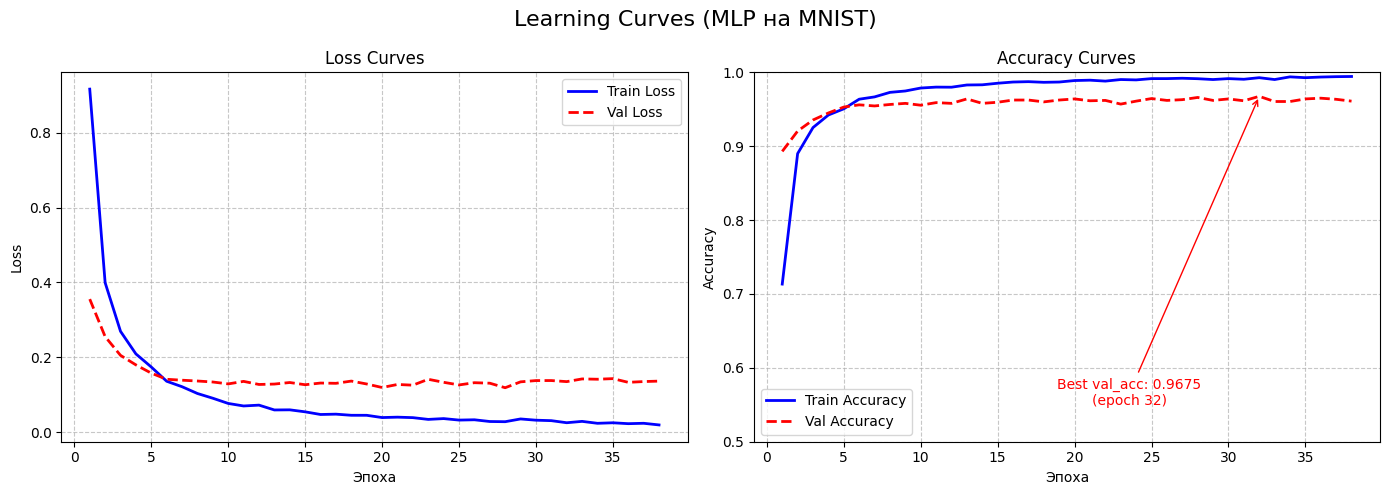

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves (MLP на MNIST)', fontsize=16)

# Loss
ax = axes[0]
ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
ax.plot(epochs, history['val_loss'], 'r--', label='Val Loss', linewidth=2)
ax.set_xlabel('Эпоха'); ax.set_ylabel('Loss')
ax.set_title('Loss Curves'); ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

# Accuracy
ax = axes[1]
if 'train_acc' in history and history['train_acc']:
    ax.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
if 'val_acc' in history and history['val_acc']:
    ax.plot(epochs, history['val_acc'], 'r--', label='Val Accuracy', linewidth=2)
ax.set_xlabel('Эпоха'); ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Curves'); ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
ax.set_ylim(0.5, 1.0)

# Аннотация
if 'val_acc' in history and history['val_acc']:
    best_val_acc = max(history['val_acc'])
    best_epoch = np.argmax(history['val_acc']) + 1
    ax.annotate(f'Best val_acc: {best_val_acc:.4f}\n(epoch {best_epoch})',
                xy=(best_epoch, best_val_acc), 
                xytext=(0.6, 0.1), textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=10, ha='center', color='red')

plt.tight_layout()
plt.show()

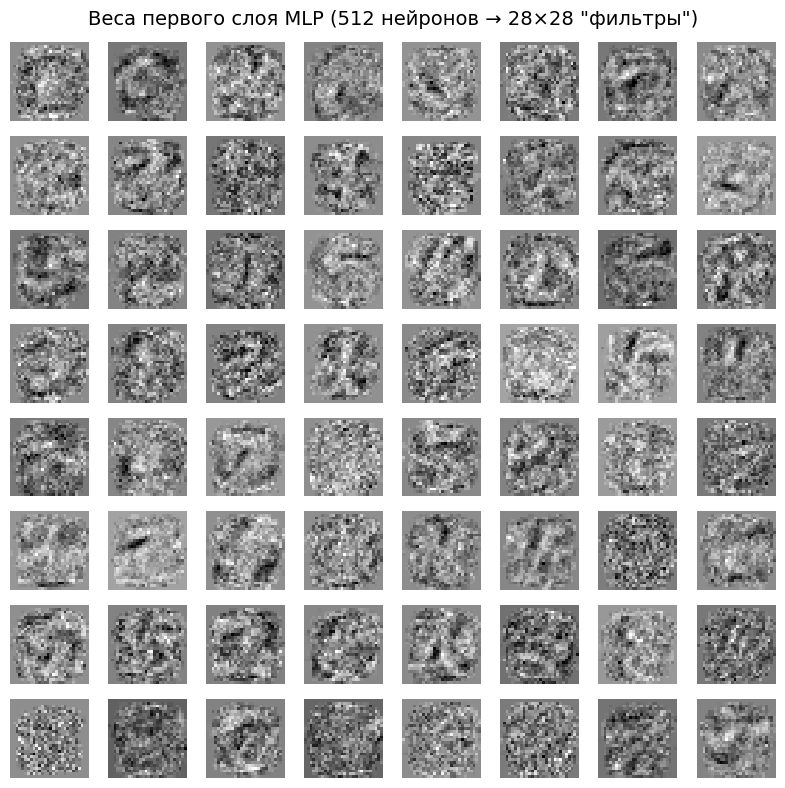

In [7]:
# Получаем веса первого слоя
W1 = mlp.W[0]

# Нормализуем для визуализации: приводим к [0, 1] по каждому нейрону
W1_vis = (W1 - W1.min(axis=1, keepdims=True)) / (W1.max(axis=1, keepdims=True) - W1.min(axis=1, keepdims=True) + 1e-8)

# Решейпим каждый вектор
filters = W1_vis.reshape(-1, 28, 28)

# Визуализируем сетку первых 64 нейронов (8×8)
n_show = 64
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.suptitle('Веса первого слоя MLP (512 нейронов → 28×28 "фильтры")', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i < n_show:
        ax.imshow(filters[i], cmap='gray', interpolation='none')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
common_params = dict(
    layer_sizes=[784, 256, 128, 10],
    activations=['relu', 'relu', 'softmax'],
    weight_init='he',
    l2_lambda=1e-4,
    dropout_rate=0.2,
    batch_norm=True,
    epochs=40,
    batch_size=128,
    patience=15
)

optimizers_config = {
    'sgd':        {'optimizer': 'sgd',        'lr': 0.01},
    'momentum':   {'optimizer': 'momentum',   'lr': 0.01, 'momentum': 0.9},
    'rmsprop':    {'optimizer': 'rmsprop',    'lr': 0.001, 'rho': 0.9},
    'adam':       {'optimizer': 'adam',       'lr': 0.001, 'beta1': 0.9, 'beta2': 0.999}
}

np.random.seed(1)  # для воспроизводимости
results = {}

for name, opt_params in optimizers_config.items():
    print(f"\n▶ Обучение с {name.upper()}...")
    
    # Создаём модель
    mlp = MyMLP(**common_params, **opt_params)
    
    # Обучаем
    hist = mlp.fit(
        X_train, y_train,
        X_val=X_val, y_val=y_val,
        epochs=common_params['epochs'],
        batch_size=common_params['batch_size'],
        patience=common_params['patience']
    )
    
    # Оценка
    y_pred = mlp.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)
    
    # Сохраняем результаты
    results[name] = {
        'train_loss': hist['train_loss'],
        'val_loss': hist['val_loss'],
        'val_acc': val_acc,
        'epochs_run': len(hist['train_loss'])
    }
    
    print(f"{name.upper()}: val_acc = {val_acc:.4f} (эпох: {results[name]['epochs_run']})")


▶ Обучение с SGD...
Epoch   1/40 | train_loss: 2.134122 | train_acc: 0.2665 | val_loss: 1.503725 | val_acc: 0.5550
Epoch   5/40 | train_loss: 0.918841 | train_acc: 0.7232 | val_loss: 0.698870 | val_acc: 0.8115
Epoch  10/40 | train_loss: 0.642280 | train_acc: 0.8104 | val_loss: 0.506286 | val_acc: 0.8555
Epoch  15/40 | train_loss: 0.526491 | train_acc: 0.8474 | val_loss: 0.424634 | val_acc: 0.8745
Epoch  20/40 | train_loss: 0.454973 | train_acc: 0.8708 | val_loss: 0.378373 | val_acc: 0.8855
Epoch  25/40 | train_loss: 0.407607 | train_acc: 0.8806 | val_loss: 0.346323 | val_acc: 0.8955
Epoch  30/40 | train_loss: 0.381315 | train_acc: 0.8856 | val_loss: 0.322850 | val_acc: 0.9025
Epoch  35/40 | train_loss: 0.349527 | train_acc: 0.8984 | val_loss: 0.304582 | val_acc: 0.9090
Epoch  40/40 | train_loss: 0.340621 | train_acc: 0.9009 | val_loss: 0.290597 | val_acc: 0.9105
SGD: val_acc = 0.9105 (эпох: 40)

▶ Обучение с MOMENTUM...
Epoch   1/40 | train_loss: 1.270041 | train_acc: 0.5927 | val_los

In [9]:
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ ОПТИМИЗАТОРОВ")
print("="*60)
print(f"{'Оптимизатор':<12} | {'Val Acc':<10} | {'Эпох':<6} | {'Лучшая эпоха'}")
print("-"*60)
for name, res in results.items():
    best_epoch = np.argmin(res['val_loss']) + 1 if res['val_loss'] else '–'
    print(f"{name.upper():<12} | {res['val_acc']:<10.4f} | {res['epochs_run']:<6} | {best_epoch}")
print("="*60)


ИТОГОВЫЕ РЕЗУЛЬТАТЫ СРАВНЕНИЯ ОПТИМИЗАТОРОВ
Оптимизатор  | Val Acc    | Эпох   | Лучшая эпоха
------------------------------------------------------------
SGD          | 0.9105     | 40     | 40
MOMENTUM     | 0.9535     | 40     | 39
RMSPROP      | 0.9585     | 31     | 16
ADAM         | 0.9575     | 31     | 16


- SGD без momentum показал худший результат и не сошёлся за 40 эпох — подтверждает необходимость инерции или адаптивности для эффективного обучения.
- Momentum значительно улучшил и точность, и сходимость — сеть обучалась дольше, но стабильнее.
- RMSprop и Adam достигли высокой точности быстрее, что говорит об эффективной адаптации шага; RMSprop чуть опередил Adam, возможно, из-за особенностей данных или гиперпараметров.

In [10]:
lrs = [1e-4, 5e-4, 1e-3, 5e-3]
bss = [32, 64, 128, 256]

print("lr\tbs\tacc")
for lr in lrs:
    for bs in bss:
        np.random.seed(0)
        mlp = MyMLP([784, 256, 128, 10], ['relu','relu','softmax'],
                    optimizer='adam', lr=lr, weight_init='he',
                    l2_lambda=1e-4, dropout_rate=0.2)
        h = mlp.fit(X_train, y_train, X_val, y_val,
                    epochs=15, batch_size=bs, patience=5, output=False)
        acc = max(h['val_acc']) if h['val_acc'] else 0
        print(f"{lr:.0e}\t{bs}\t{acc:.4f}")

lr	bs	acc


1e-04	32	0.9410
1e-04	64	0.9280
1e-04	128	0.9160
1e-04	256	0.9015
5e-04	32	0.9595
5e-04	64	0.9565
5e-04	128	0.9520
5e-04	256	0.9435
1e-03	32	0.9530
1e-03	64	0.9580
1e-03	128	0.9610
1e-03	256	0.9505
5e-03	32	0.9460
5e-03	64	0.9555
5e-03	128	0.9530
5e-03	256	0.9525


Наилучшая точность достигнута при learning rate = 1e−3 и batch size = 128 — это «золотая середина»: достаточно большой lr для быстрого продвижения и умеренный размер батча, обеспечивающий баланс между шумом градиента и стабильностью. При малых lr (1e−4) точность растёт с уменьшением batch size, а при больших lr (5e−3) — наблюдается насыщение и небольшое падение качества при малых батчах. Видна общая тенденция: при увеличении lr оптимальный batch size смещается в сторону больших значений.

### 4. Сравнение с PyTorch/TensorFlow
Реализовать аналогичную MLP в PyTorch или TensorFlow и сравнить training time и final accuracy.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from time import time

# Для PyTorch — тензоры
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train.values).long()
X_val_t = torch.from_numpy(X_val).float()
y_val_t = torch.from_numpy(y_val.values).long()

class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

def train_torch():
    model = TorchMLP()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=128, shuffle=True)
    
    model.train()
    start = time()
    for epoch in range(40):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
    torch_time = time() - start
    
    model.eval()
    with torch.no_grad():
        pred = model(X_val_t).argmax(dim=1)
        acc = (pred == y_val_t).float().mean().item()
    
    return acc, torch_time

In [14]:
def train_custom():
    mlp = MyMLP(
        layer_sizes=[784, 512, 256, 128, 10],
        activations=['relu', 'relu', 'relu', 'softmax'],
        optimizer='adam', lr=0.001,
        weight_init='he', l2_lambda=1e-4,
        dropout_rate=0.2, batch_norm=True
    )
    start = time()
    mlp.fit(X_train, y_train, X_val, y_val,
            epochs=40, batch_size=128, patience=100, output=False)
    custom_time = time() - start
    y_pred = mlp.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    return acc, custom_time

# Запуск
print("▶ Обучение PyTorch MLP...")
acc_torch, time_torch = train_torch()

print("▶ Обучение Custom MLP...")
acc_custom, time_custom = train_custom()

# Вывод
print("\n" + "="*50)
print(f"{'Модель':<15} | {'Точность':<10} | {'Время (с)'}")
print("-"*50)
print(f"{'PyTorch':<15} | {acc_torch:.4f}   | {time_torch:.2f}")
print(f"{'Custom':<15} | {acc_custom:.4f}   | {time_custom:.2f}")
print("="*50)

▶ Обучение PyTorch MLP...
▶ Обучение Custom MLP...

Модель          | Точность   | Время (с)
--------------------------------------------------
PyTorch         | 0.9625   | 72.41
Custom          | 0.9675   | 164.36


### 5. Выводы
- Оценить преимущества разных оптимизаторов.

    Преимущества разных оптимизаторов проявляются в балансе между скоростью сходимости, стабильностью и качеством обобщения. Adam обеспечивает быстрый и надёжный старт в большинстве задач, особенно при отсутствии времени на тонкую настройку, но может давать худшее обобщение по сравнению с SGD+momentum в задачах компьютерного зрения. RMSprop остаётся актуален для рекуррентных моделей и нестационарных целей.

- Проанализировать влияние архитектуры и регуляризации.

    Увеличение глубины/ширины MLP повышает ёмкость модели, но резко усиливает склонность к переобучению без контрмер. Регуляризация (L2, dropout, BN, early stopping) не просто «дополнение», а необходимое условие стабильного обучения глубоких MLP. BatchNorm ускоряет сходимость и позволяет использовать более высокие learning rate’ы, dropout улучшает робастность к шуму и разнообразит внутренние представления, а L2 и early stopping действуют как «тормоза», предотвращая подгонку под обучающую выборку. Оптимальный результат достигается не максимизацией сложности архитектуры, а балансом между выразительной силой и контролем переобучения.